### Inteligencia Artificial - Examen 1 (Único 😊)
#### D. Martínez - 2025 S1
----
##### Presentado por: {Su nombre completo} - {nickname correo UNAL}

Se quiere realizar un clasificador que permita identificar la posibilidad de contagio de un virus mortal en una población. Se realiza una prueba que tiene un trazo de 2 biomarcadores que se asocian con el virus. Su misión es iniciar el desarrollo de un modelo de red neuronal profunda (DNN) que pueda ser entrenada para crear un modelo de clasificación.

Siga las instrucciones a continuación para el desarrollo del modelo.

In [2]:
# Importar las bibliotecas requeridas
# - -- --- ----- ------- ---------- -------------
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt
# Import another math library
import math

In [3]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  """Función ReLU
  La función Relu Rectified Linear Unit, convoerte a cero los valores menores a
  cero de la preactivación

  :param ndarray preactivation: preactivación de la neurona

  :return: activation, la activación de la neurona
  :rtype: ndarray
  """
  activation = preactivation.clip(0.0)
  return activation

In [4]:
def sigmoidal(model_out):
  """Función sigmoidal
  La función sigmoidal es una función de activación a utilizar en la neurona
  final.

  :params double model_out: salida original de la neurona

  :return: activation, valor [0,1] resultado de la función logística
  :rtype: double
  """
  activation = 1 / (1 + np.exp(-model_out))
  return activation

Distribución de __Bernoulli__:
$$\mathbb{P}[y\mid\lambda]=(1-\lambda)^{1-y}\cdot\lambda^{y}$$

In [5]:

def bernoulli_distribution(y, lambda_param):
  """Función de distribución de Bernoulli
  Calcula la probabilidad bajo la distribución de Bernoulli para una clase
  observada y

  :params ndarray y: la clase
  :params double lambda_param: el valor del parametro lambda de la distribución
  :returns: prob, el vector de probabilidades
  :rtype: ndarray
  """
  # TODO-- escriba la ecuación de la distribución de probabilidad de bernoulli
  prob = ((1-lambda_param)**(1-y))*((lambda_param)**y)

  return prob

La siguiente es la arquitectura de la red profunda que se quiere usar en la clasificación

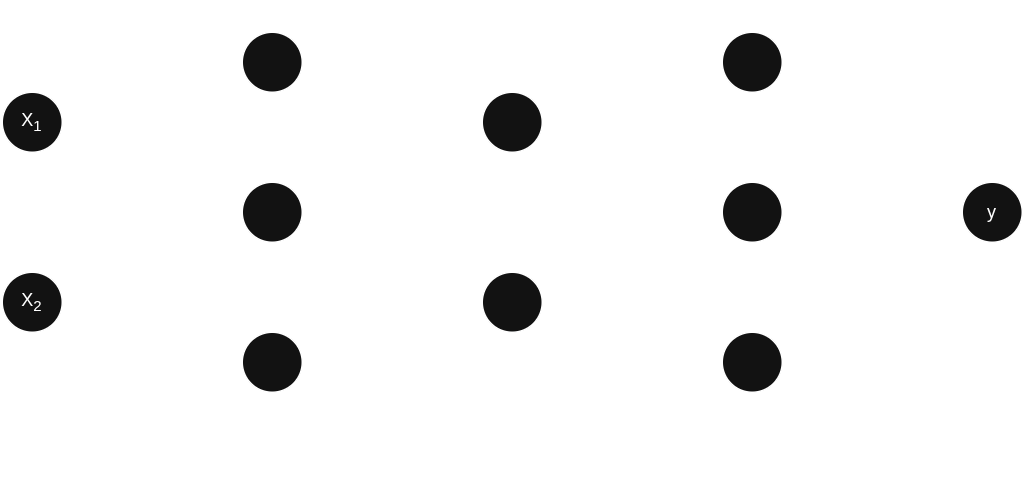

Defina una función que calcule un $\hat{y}$ tomando como base la arquitectura de la DNN de la imagen y un conjunto de valores $\mathbf{x}=\{x_1, x_2\}$ y un conjunto de pesos $W$ para cada capa, de manera de $W_{10}$ representa el sesgo de la capa 1 mientras $W_{11}$ representa los pesos hacia la primer capa. La función retorna el valor estimado de ___y___ ($\hat{y}$). La función de activación de las unidades internas es ReLU, mientras que la función de activación de la ultima neurona ___y___ debe ser una función sigmoidal

__Nota__: _Recuerde la parte final del notebook de deep_networks con la multiplicación de matrices para el modelo_

In [13]:
# crear un DNN con tres capas ocultas. D_i=2, D_1=3, D_2=2, D_3=3 y D_o=1
def deep_nn(x, W_10, W_11, W_20, W_21, W_30, W_31, W_F0, W_F1):
  """ Deep Neural Network

  Modelo de red neuronal de tres capas ocultas para el calculo de la función de
  clasificación binaria.

  :params ndarray x: datos de entrada
  :params ndarray W_10: sesgo de la capa 1
  :params ndarray W_11: pesos de la capa 1
  :params ndarray W_20: sesgo de la capa 2
  :params ndarray W_21: pesos de la capa 2
  :params ndarray W_30: sesgo de la capa 3
  :params ndarray W_31: pesos de la capa 3
  :params ndarray W_F0: sesgo de la capa de salida (Final)
  :params ndarray W_F1: pesos de la capa de salida (Final)
  :return: valores entre cero y uno correspondiente al valor asignado al final
           para cada x
  :rtype: ndarray
  """
  # TODO: cree las capas de la red utilizando la función Relu en las capas
  #       internas y la sigmoidal en el resultado de la ultima capa.
  # A continuación se muestra la capa oculta uno  ReLU(W_10 + W_11 * x)
  h1 = ReLU(W_10 + np.matmul(W_11,x.T))

  h2 = ReLU(W_20 + np.matmul(W_21,h1))

  h3 = ReLU(W_30 + np.matmul(W_31, h2))




  y_est = sigmoidal(W_F0 + np.matmul(W_F1, h3)) # reemplazar esta linea con el resultado de la red

  return y_est.T


Ahora que el modelo le da valores entre [0,1], y que representan la probabilidad de tener el virus, es decir, $y=1$ tiene el virus mientras $y=0$ no lo tiene, puede calcular el negative log likelihood (NLL) y estimar la perdida del modelo
$$ L[\phi] = \sum_{i=1}^{I} -(1-y_{i})\log(1-\lambda)-y_{i}\log(\lambda)$$


In [10]:
def negative_log_likelihood( y_train, lambda_param):
  """ Negative Log Likelihood
  Calcula el Negative log likelihood como función de perdida

  :params ndarray y_train: etiquetas correctas del modelo
  :params ndarray lambda_param: valores de lambda estimados por el modelo

  :return: valor de la función de perdida
  :rtype: float
  """
  # TODO: Calcule el Negative Log Likelihood para la función de bernulli. reemplace la linea siguiente
  epsilon = 1e-15
  lambda_param = np.clip(lambda_param, epsilon, 1 - epsilon)
    
  # L = -sum[ (1-y)log(1-lambda) + ylog(lambda) ]
  term_0 = (1 - y_train) * np.log(1 - lambda_param)
  term_1 = y_train * np.log(lambda_param)
  nll = -np.sum(term_0 + term_1)
  return nll



##### __Opcional__
Cree una función que actualice los valores de los pesos de la última capa a partir del valor obtenido

$$ \phi_{j} \leftarrow \phi_{j} - \alpha \cdot \frac{1}{\mid I \mid}\sum_{i=1}^{I}(\hat{y}^{i}- y^{i})x^{i}$$

donde $\mid I \mid$ es el número de elementos, e $i$ indica el elemento $i$-esimo


In [11]:
def derivada_modelo_ultima_capa(W_F0, W_F1, data_X, data_Y, pred_Y, learning_rate=0.05):
  """ Derivada para la última capa

  :params ndarray W_F0: sesgo de la capa final
  :params ndarray W_F1: pesos de la capa final
  :params ndarray data_X: datos de entrada
  :params ndarray data_Y: etiquetas correctas del modelo
  :params ndarray pred_Y: predicción del modelo
  :params float learning_rate: tasa de aprendizaje

  :return: W_F0_new, W_F1_new, valores actualizados de los pesos de la capa final
  :rtype: ndarray, ndarray
  """
  # TODO: actualizar los pesos de la ultima capa (incluyendo el sesgo). reemplace las siguientes lineas
  # Error: (y_hat - y)
  error = (pred_Y - data_Y) # (N, 1)
  I = len(data_Y)
    
  # Gradiente simplificado para el sesgo (W_F0)
  grad_W_F0 = np.sum(error) / I
  W_F0_new = W_F0 - learning_rate * grad_W_F0
    
    # Gradiente simplificado para los pesos (W_F1)
    # Nota: Para ser exactos requeriría h3, pero seguimos la fórmula del prompt
  grad_W_F1 = np.matmul(error.T, data_X) / I
  W_F1_new = W_F1 - learning_rate * grad_W_F1
    
  return W_F0_new, W_F1_new


Finalmente para probar el código desarrollado para la parte inicial del modelo de clasificación:

1. Cree un conjunto de datos de prueba ___X___ y ___y___ aleatorios.
2. Cree valores de pesos aleatorios para probar el modelo. Es decir cada una de las matrices $W_{ij}$ que se requieren para estimar los valores.
3. Ejecute el modelo con los datos de entrada y con tres valores de pesos aleatorios y calcule la perdida con cada uno.
4. Escriba un párrafo de conclusión del ejercicio soportado en los resultados obtenidos

In [14]:
n_datos=30
# 1. Datos aleatorios
X = np.random.randn(n_datos, 2)
y = np.random.randint(0, 2, (n_datos, 1))

# Función auxiliar para inicializar pesos
def init_weights(out_dim, in_dim):
    return np.random.randn(out_dim, 1), np.random.randn(out_dim, in_dim)

perdidas = []

for i in range(3):
    # 2. Generar pesos aleatorios en cada iteración
    W_10, W_11 = init_weights(3, 2)
    W_20, W_21 = init_weights(2, 3)
    W_30, W_31 = init_weights(3, 2)
    W_F0, W_F1 = init_weights(1, 3)
    
    # 3. Ejecutar modelo y calcular pérdida
    y_hat = deep_nn(X, W_10, W_11, W_20, W_21, W_30, W_31, W_F0, W_F1)
    loss = negative_log_likelihood(y, y_hat)
    perdidas.append(loss)

print(f"Las pérdidas del modelo son: {perdidas}")

Las pérdidas del modelo son: [np.float64(19.119694192210503), np.float64(21.508546237518154), np.float64(18.90693497972849)]


#### Conclusión
----
escriba aquí su conclusión